In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set(style="whitegrid")



In [3]:
# Load Dataset
df = pd.read_csv("dataset.csv")
df.head()

,name,description,make,model,year,price,engine,cylinders,fuel,mileage,transmission,trim,body,doors,exterior_color,interior_color,drivetrain
0,2024 Jeep Wagoneer Series II,"\n \n Heated Leather Seats, Nav Sy...",Jeep,Wagoneer,2024,74600.0,24V GDI DOHC Twin Turbo,6.0,Gasoline,10.0,8-Speed Automatic,Series II,SUV,4.0,White,Global Black,Four-wheel Drive
1,2024 Jeep Grand Cherokee Laredo,Al West is committed to offering every custome...,Jeep,Grand Cherokee,2024,50170.0,OHV,6.0,Gasoline,1.0,8-Speed Automatic,Laredo,SUV,4.0,Metallic,Global Black,Four-wheel Drive
2,2024 GMC Yukon XL Denali,NaN,GMC,Yukon XL,2024,96410.0,"6.2L V-8 gasoline direct injection, variable v...",8.0,Gasoline,0.0,Automatic,Denali,SUV,4.0,Summit White,Teak/Light Shale,Four-wheel Drive
3,2023 Dodge Durango Pursuit,White Knuckle Clearcoat 2023 Dodge Durango Pur...,Dodge,Durango,2023,46835.0,16V MPFI OHV,8.0,Gasoline,32.0,8-Speed Automatic,Pursuit,SUV,4.0,White Knuckle Clearcoat,Black,All-wheel Drive
4,2024 RAM 3500 Laramie,\n \n 2024 Ram 3500 Laramie Billet...,RAM,3500,2024,81663.0,24V DDI OHV Turbo Diesel,6.0,Diesel,10.0,6-Speed Automatic,Laramie,Pickup Truck,4.0,Silver,Black,Four-wheel Drive


In [4]:
# Basic Dataset Information
# Shape of dataset
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

# Column info
df.info()


Rows: 1002
Columns: 17
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1002 entries, 0 to 1001
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   name            1002 non-null   object 
 1   description     946 non-null    object 
 2   make            1002 non-null   object 
 3   model           1002 non-null   object 
 4   year            1002 non-null   int64  
 5   price           979 non-null    float64
 6   engine          1000 non-null   object 
 7   cylinders       897 non-null    float64
 8   fuel            995 non-null    object 
 9   mileage         968 non-null    float64
 10  transmission    1000 non-null   object 
 11  trim            1001 non-null   object 
 12  body            999 non-null    object 
 13  doors           995 non-null    float64
 14  exterior_color  997 non-null    object 
 15  interior_color  964 non-null    object 
 16  drivetrain      1002 non-null   object 
dtypes: float64

In [5]:

# Check Missing Values
missing = df.isnull().sum().sort_values(ascending=False)
missing_percent = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Values": missing,
    "Missing %": missing_percent
})

missing_df[missing_df["Missing Values"] > 0]


,Missing Values,Missing %
cylinders,105,10.479042
description,56,5.588822
interior_color,38,3.792415
mileage,34,3.393214
price,23,2.295409
fuel,7,0.698603
doors,7,0.698603
exterior_color,5,0.499002
body,3,0.299401
engine,2,0.199601


In [6]:
# Statistical Summary Numerical features
df.describe().T

,count,mean,std,min,25%,50%,75%,max
year,1002.0,2023.916168,0.298109,2023.0,2024.0,2024.0,2024.0,2025.0
price,979.0,50202.985700,18700.392062,0.0,36600.0,47165.0,58919.5,195895.0
cylinders,897.0,4.975474,1.392526,0.0,4.0,4.0,6.0,8.0
mileage,968.0,69.033058,507.435745,0.0,4.0,8.0,13.0,9711.0
doors,995.0,3.943719,0.274409,2.0,4.0,4.0,4.0,5.0


In [7]:
# Separate Numerical and Categorical Columns
num_cols = df.select_dtypes(include=["int64", "float64"]).columns
cat_cols = df.select_dtypes(include=["object"]).columns

print("Numerical Columns:", num_cols)
print("Categorical Columns:", cat_cols)


Numerical Columns: Index(['year', 'price', 'cylinders', 'mileage', 'doors'], dtype='object')
Categorical Columns: Index(['name', 'description', 'make', 'model', 'engine', 'fuel',
       'transmission', 'trim', 'body', 'exterior_color', 'interior_color',
       'drivetrain'],
      dtype='object')


#### Target Variable Analysis(Price)

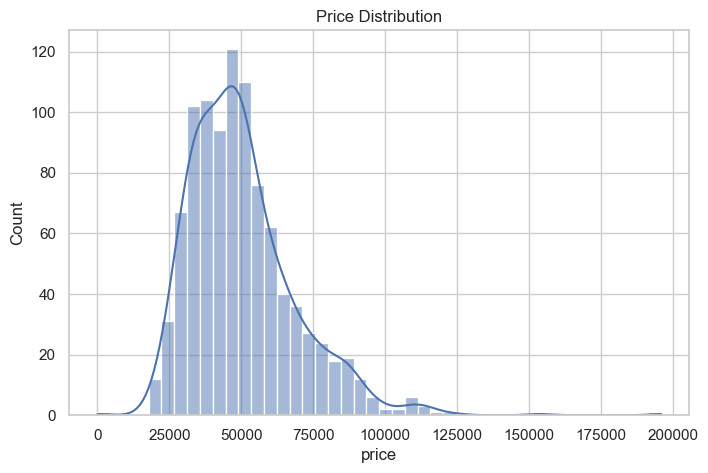

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(df["price"], kde=True)
plt.title("Price Distribution")
plt.show()

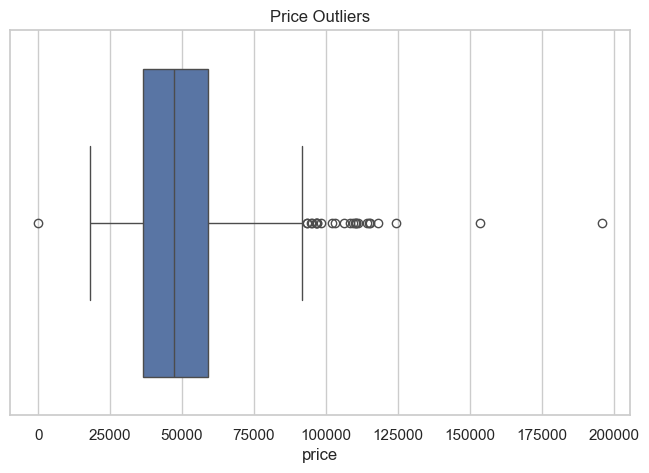

In [10]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["price"])
plt.title("Price Outliers")
plt.show()


#### Vechicle Age Analysis

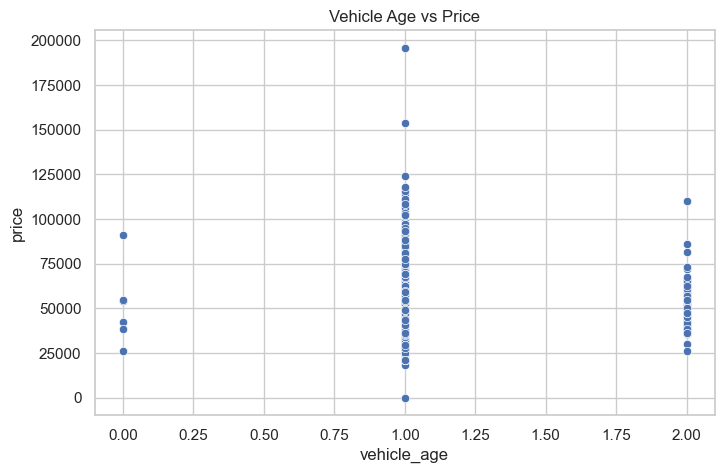

In [12]:
df["vehicle_age"] = df["year"].max() - df["year"]

plt.figure(figsize=(8,5))
sns.scatterplot(x=df["vehicle_age"], y=df["price"])
plt.title("Vehicle Age vs Price")
plt.show()


#### Mileage Vs Price

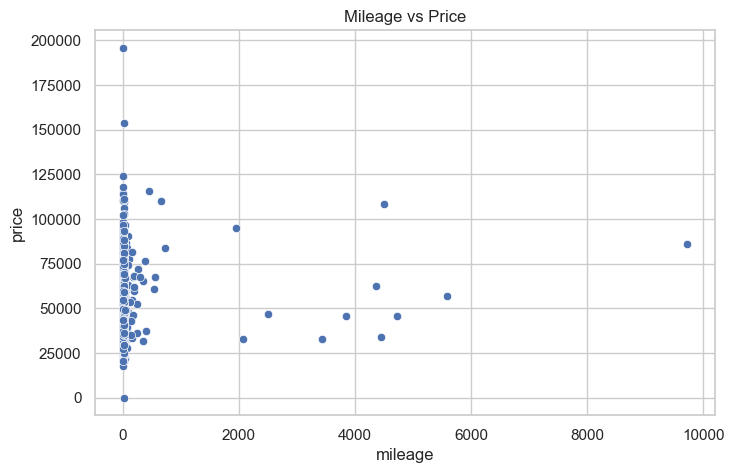

In [13]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df["mileage"], y=df["price"])
plt.title("Mileage vs Price")
plt.show()


### Categorical Feature Analysis


#### Price by Fuel Type

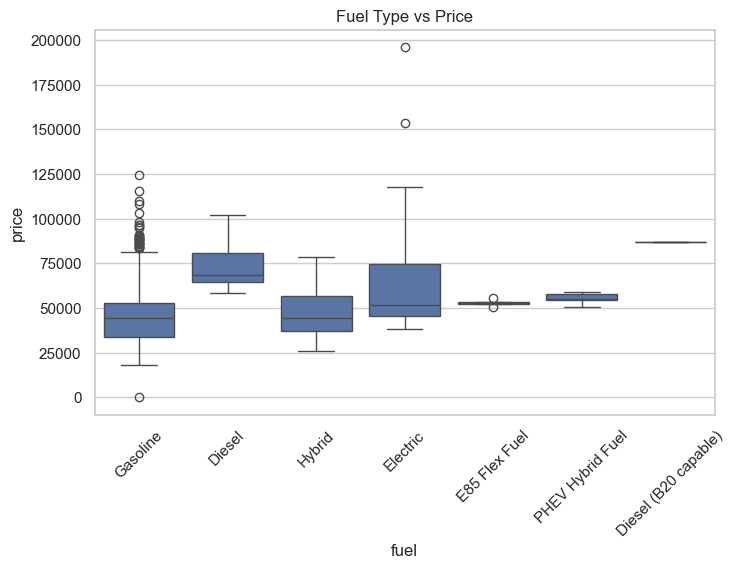

In [14]:
plt.figure(figsize=(8,5))
sns.boxplot(x="fuel", y="price", data=df)
plt.xticks(rotation=45)
plt.title("Fuel Type vs Price")
plt.show()


#### Price by Transmission

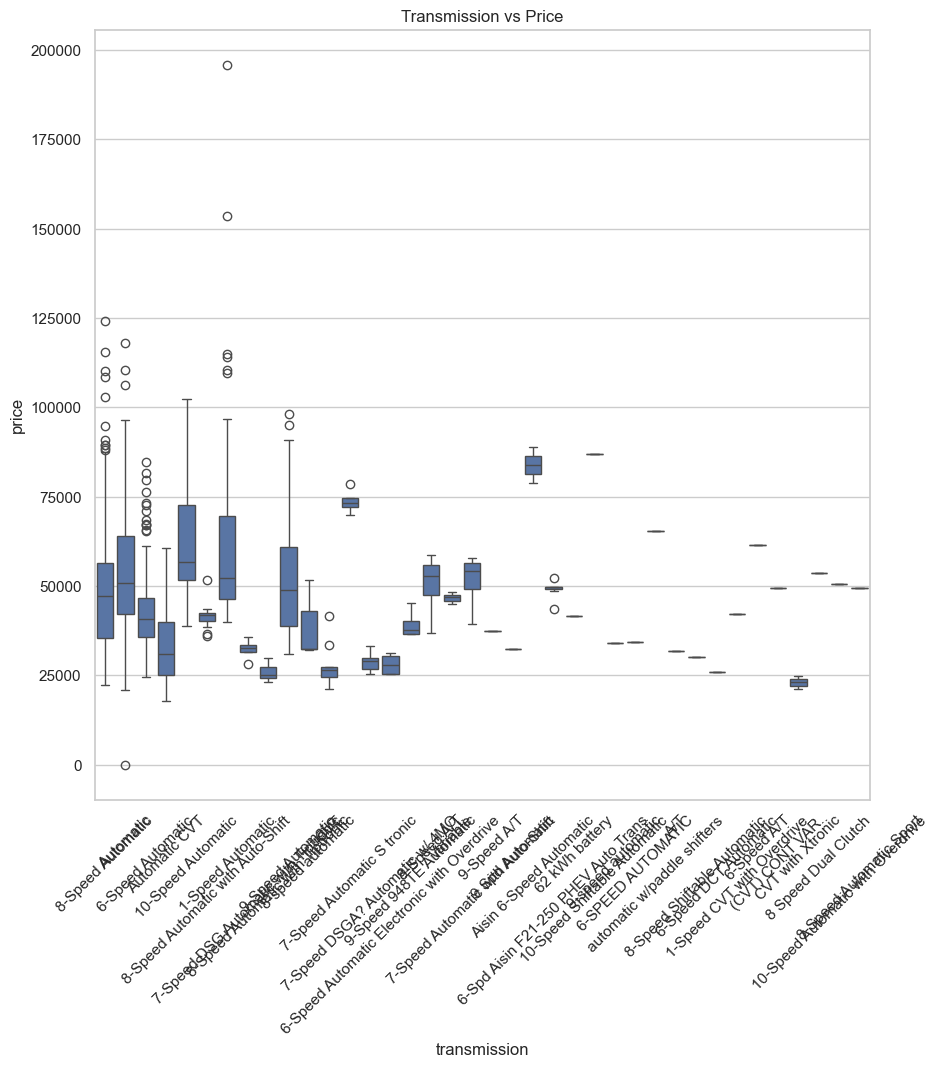

In [17]:
plt.figure(figsize=(10,10))
sns.boxplot(x="transmission", y="price", data=df)
plt.xticks(rotation=45)
plt.title("Transmission vs Price")
plt.show()


#### Price by Body Type

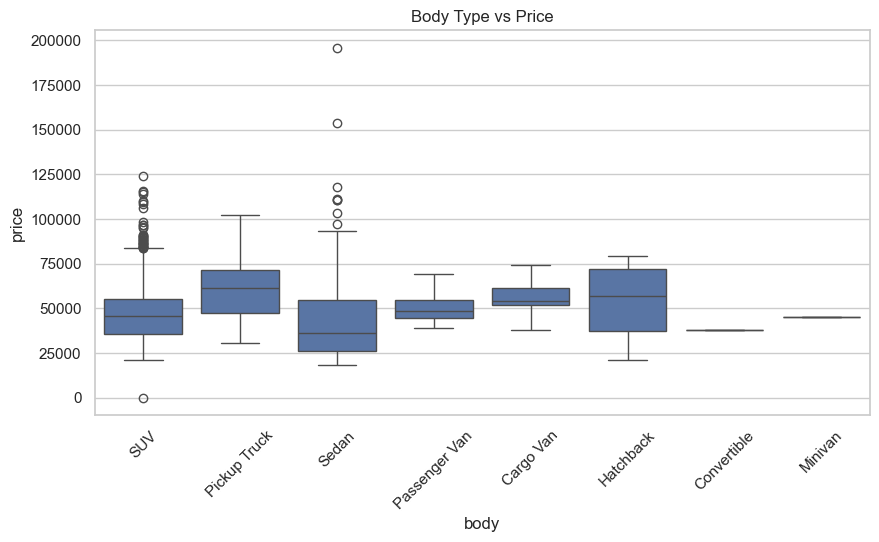

In [18]:
plt.figure(figsize=(10,5))
sns.boxplot(x="body", y="price", data=df)
plt.xticks(rotation=45)
plt.title("Body Type vs Price")
plt.show()


#### Correlation Heatmap (Numerical Only)

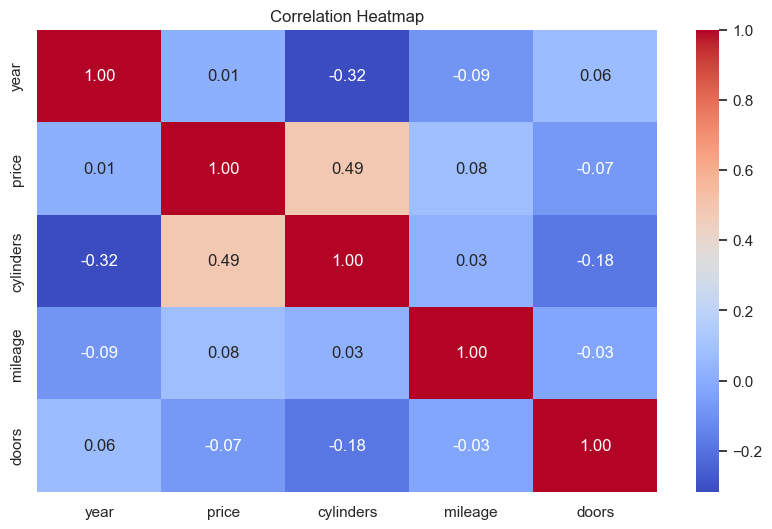

In [19]:
plt.figure(figsize=(10,6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


#### Top Makes by Average Price

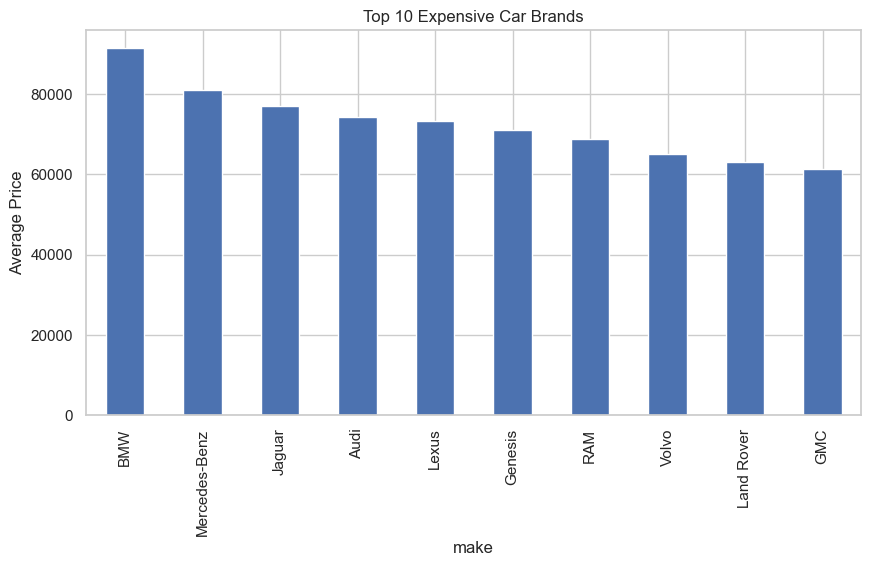

In [20]:
top_makes = (
    df.groupby("make")["price"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

top_makes.plot(kind="bar", figsize=(10,5), title="Top 10 Expensive Car Brands")
plt.ylabel("Average Price")
plt.show()


#### Key EDA Insights (You can use this in report)

• Price is right-skewed with high-end outliers

• Newer vehicles tend to have higher prices

• Mileage has a strong negative impact on price

• Fuel type, body type, and transmission significantly affect pricing

• Brand (make) plays a major role in price variation
